<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [18]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")

---


# Test Environment


In [27]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
# Prompt
'''
Write a python code to perform the following actions.
1. Import a data set from a CSV file, The headers for the data set must be in the first row of the CSV file.
2. Generate the statistical description of all the features used in the data set. Include "object" data types as well.
'''
# Import necessary libraries
import pandas as pd

# URL of the CSV file
url = "dataset.csv"

# Step 1: Import the dataset from the CSV file
data = pd.read_csv(url)
    
# Step 2: Generate statistical description of all features
# This includes counting non-null values, unique values for object (categorical) columns, mean, std, min, max for numerical columns.
description = data.describe(include='all')

# Print the statistical description
print(description)
# data.info()


        Unnamed: 0 Manufacturer    Category   Screen         GPU          OS  \
count   238.000000          238  238.000000      238  238.000000  238.000000   
unique         NaN           11         NaN        2         NaN         NaN   
top            NaN         Dell         NaN  Full HD         NaN         NaN   
freq           NaN           71         NaN      161         NaN         NaN   
mean    118.500000          NaN    3.205882      NaN    2.151261    1.058824   
std      68.848868          NaN    0.776533      NaN    0.638282    0.235790   
min       0.000000          NaN    1.000000      NaN    1.000000    1.000000   
25%      59.250000          NaN    3.000000      NaN    2.000000    1.000000   
50%     118.500000          NaN    3.000000      NaN    2.000000    1.000000   
75%     177.750000          NaN    4.000000      NaN    3.000000    1.000000   
max     237.000000          NaN    5.000000      NaN    3.000000    2.000000   

          CPU_core  Screen_Size_cm  CPU

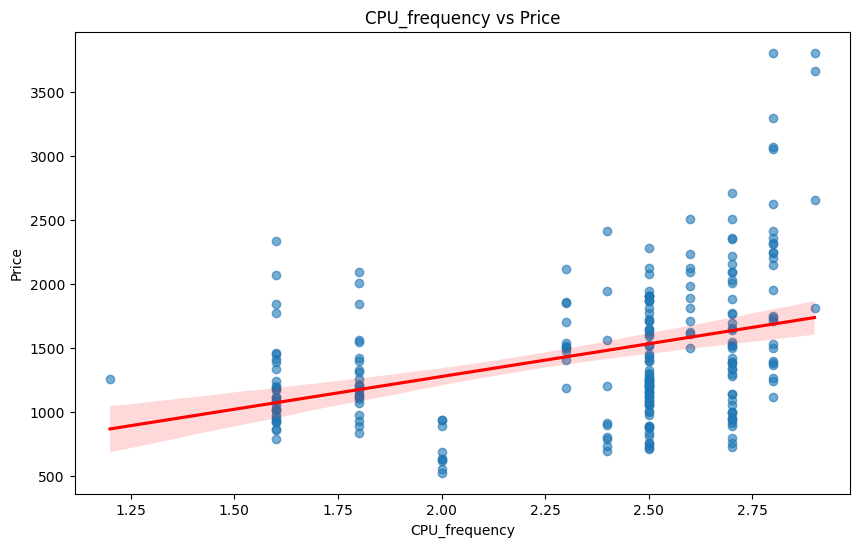

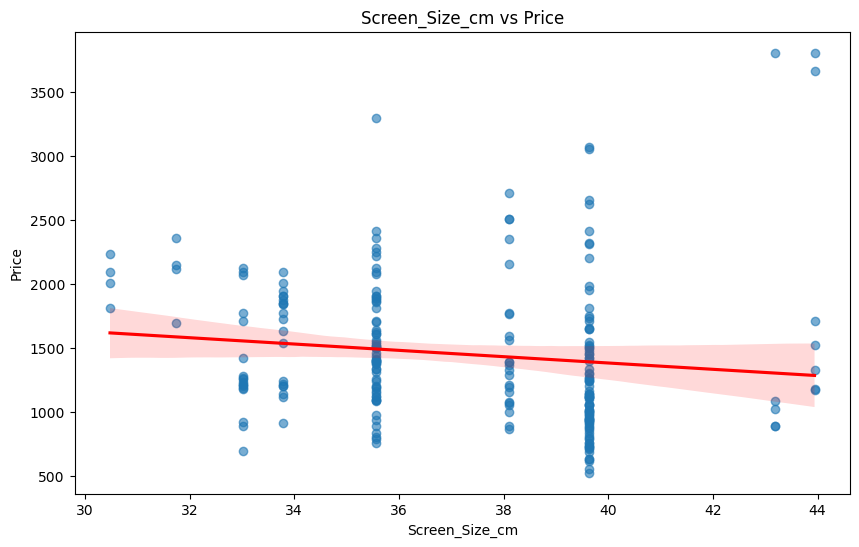

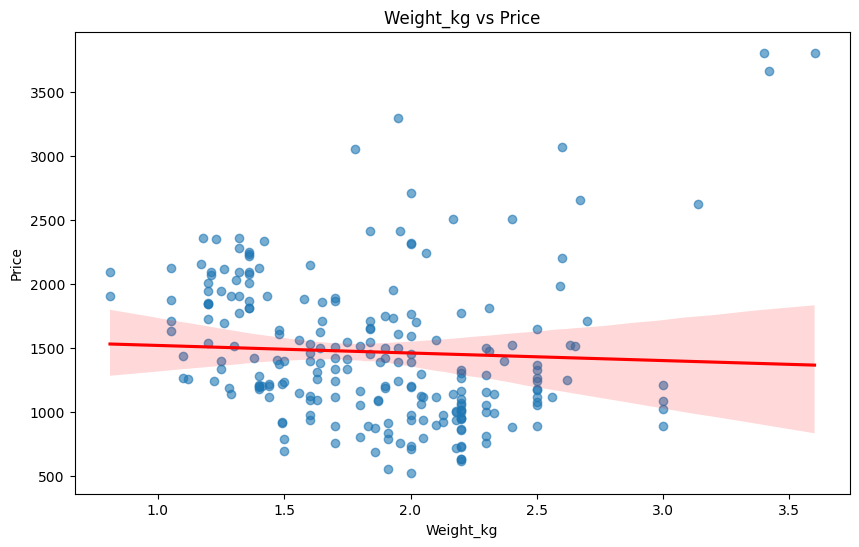

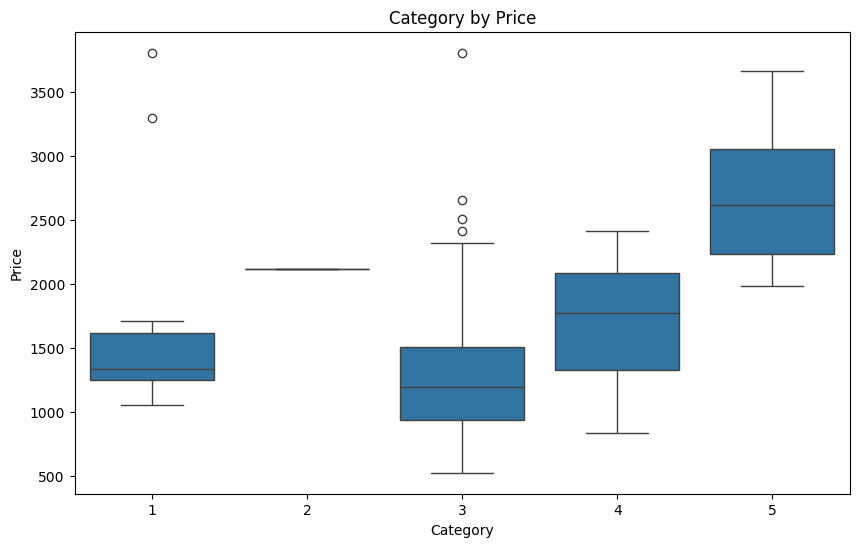

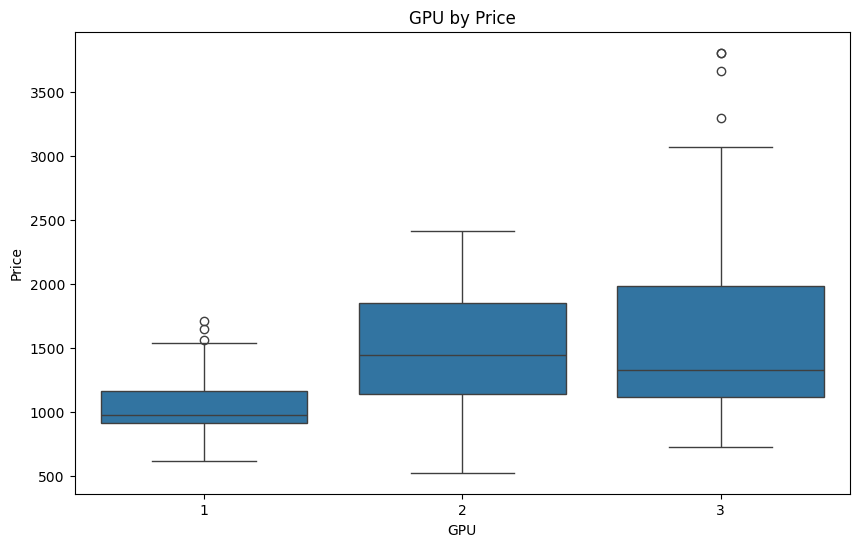

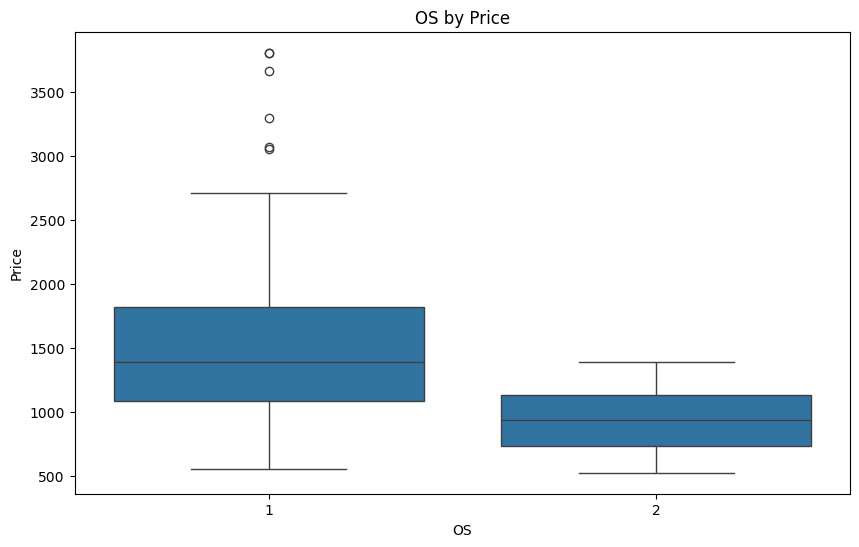

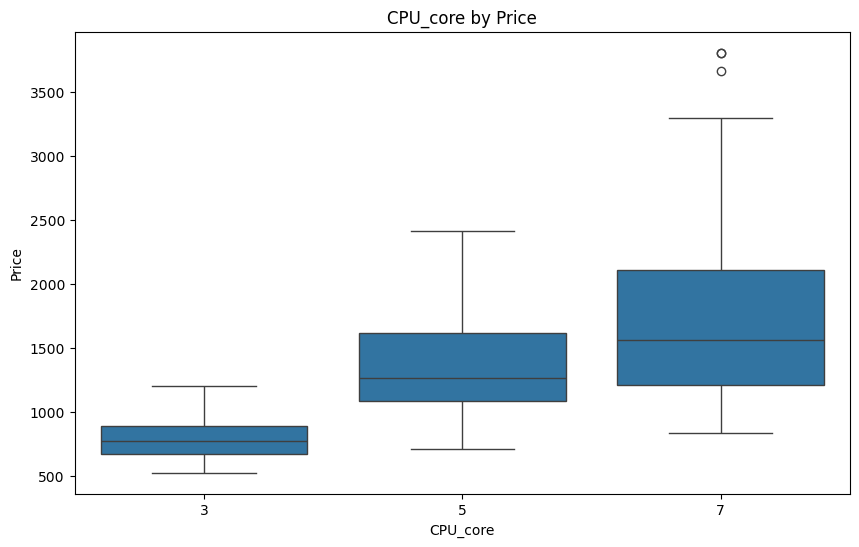

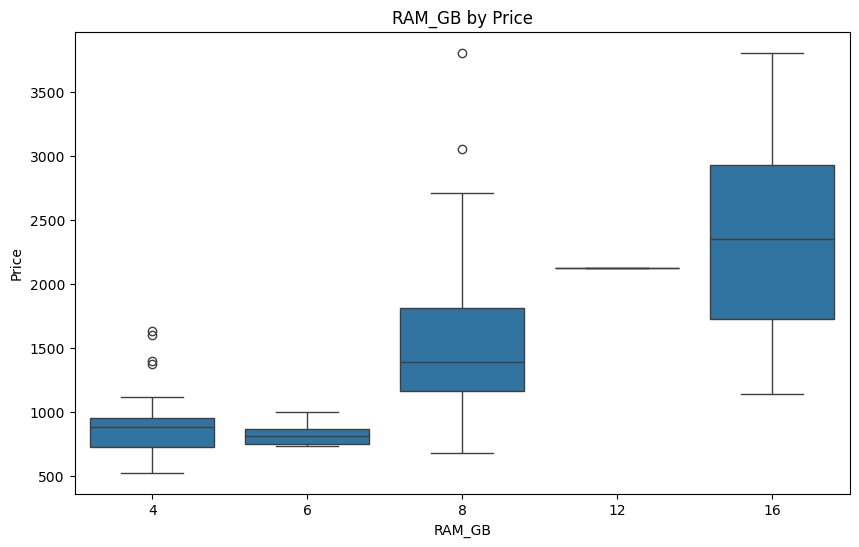

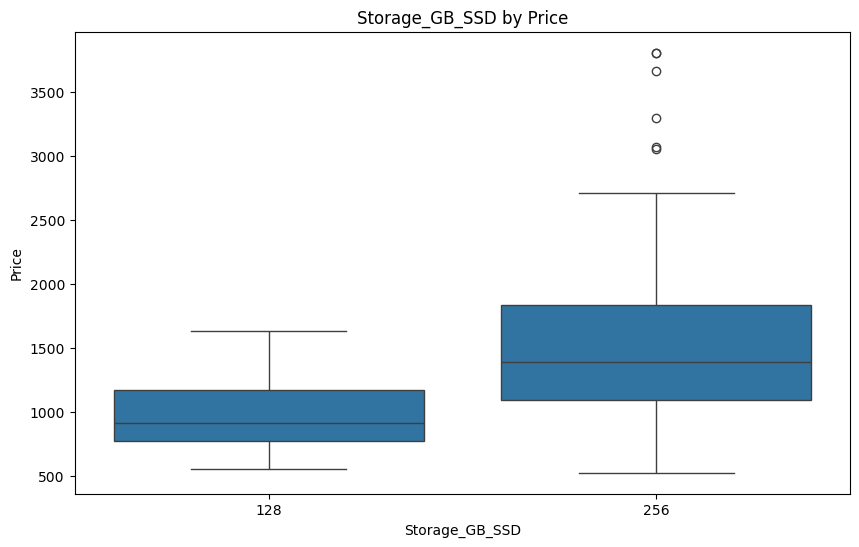

In [31]:
# Prompt
'''
Write a Python code to perform the following actions.
1. Create regression plots for the attributes "CPU_frequency", "Screen_Size_cm" and "Weight_kg" against "Price".
2. Create box plots for the attributes "Category", "GPU", "OS", "CPU_core", "RAM_GB" and "Storage_GB_SSD" against the attribute "Price".
'''

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

def plot_regression(df, x, y):
    """Create a scatter plot with a regression line for attribute 'x' against 'y'."""
    plt.figure(figsize=(10, 6))
    sns.regplot(x=x, y=y, data=df, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title(f'{x} vs Price')
    plt.xlabel(x)
    plt.ylabel('Price')
    plt.show()

def plot_boxplot(df, x, y):
    """Create a box plot comparing distribution of attribute 'x' by 'Price'."""
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=x, y=y, data=df)
    plt.title(f'{x} by Price')
    plt.xlabel(x)
    plt.ylabel('Price')
    plt.show()

# Assuming df_converted is your DataFrame
# Attributes and columns to be used for plotting
attributes = ["CPU_frequency", "Screen_Size_cm", "Weight_kg"]
price_column = "Price"

category_columns = ["Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"]

# Create regression plots
for attr in attributes:
    plot_regression(data, attr, price_column)

# Create box plots
for cat in category_columns:
    plot_boxplot(data, cat, price_column)

In [45]:
import pandas as pd

def replace_missing_with_mode(data):
    """
    Replace NaN values in 'Screen_Size_cm' column with the most frequent value.
    
    Args:
    - data: Pandas DataFrame containing the column 'Screen_Size_cm'.

    Returns:
    - A DataFrame with NaN values in 'Screen_Size_cm' replaced by the mode.
    """
    # Find the mode (most frequent value) of 'Screen_Size_cm'
    mode_value = data['Screen_Size_cm'].mode()[0]
    
    # Replace NaN values with the mode
    data['Screen_Size_cm'].fillna(mode_value, inplace=True)
    
    return data

# Assuming 'data' is your pre-defined DataFrame
# Example usage:
data = replace_missing_with_mode(data)
data.info()

<ipython-input-45-21f0fed09743>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Screen_Size_cm'].fillna(mode_value, inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  238 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 22.4+ KB


In [46]:
# Prompt
'''
Write a Python code for the following.
1. Evaluate the correlation value, pearson coefficient and p-values for all numerical attributes against the target attribute "Price".
2. Don't include the values evaluated for target variable against itself.
3. Print these values as a part of a single dataframe against each individual attribute.
'''
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Assuming your dataframe has a target attribute 'Price'
data = pd.read_csv('dataset.csv')

# Select numerical attributes
numerical_attributes = data.select_dtypes(include=np.number)

# Calculate correlation values for all numerical attributes against 'Price'
correlation_values = numerical_attributes.corr()['Price'].drop('Price')

# Calculate Pearson coefficient and p-values for all numerical attributes against 'Price'
pearson_coefficients = []
p_values = []

for column in numerical_attributes.columns:
    if column != 'Price':
        pearson_coefficient, p_value = pearsonr(numerical_attributes[column], data['Price'])
        pearson_coefficients.append(pearson_coefficient)
        p_values.append(p_value)

# Create a new dataframe to store the results
results_df = pd.DataFrame({'Attribute': correlation_values.index, 'Correlation Value': correlation_values, 'Pearson Coefficient': pearson_coefficients, 'P-value': p_values})

# Print the results
print(results_df)

<class 'ValueError'>: array must not contain infs or NaNs

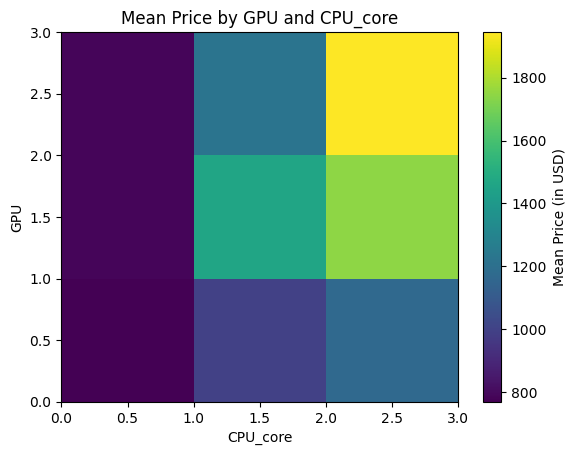

In [47]:
# Prompt
'''
Write a python code that performs the following actions.
1. Group the attributes "GPU", "CPU_core" and "Price", as available in a dataframe df
2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
3. Plot a pcolor plot for this pivot table.
'''

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_pivot_pcolor(data):
    """Plot a pcolor plot for a pivot table grouped by 'GPU', 'CPU_core', and aggregating by 'Price' mean."""
    
    # Group by 'GPU', 'CPU_core' and calculate the mean of 'Price'
    pivot_table = data.groupby(['GPU', 'CPU_core'])['Price'].mean().unstack()
    
    # Create a pcolor plot
    fig, ax = plt.subplots()
    im = ax.pcolormesh(pivot_table, cmap='viridis')
    
    # Add color bar
    cbar = fig.colorbar(im)
    cbar.ax.set_ylabel('Mean Price (in USD)')
    
    # Set labels and title
    ax.set_xlabel('CPU_core')
    ax.set_ylabel('GPU')
    ax.set_title('Mean Price by GPU and CPU_core')
    
    # Format and display the plot
    plt.show()

# Assuming 'data' is your pre-defined DataFrame with columns 'GPU', 'CPU_core', and 'Price'
# Example usage:
plot_pivot_pcolor(data)

## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
